# Introduction

### Notes

1. Might want to increase the MAX_STEP and equation length -- muzero might be able to exploit longer things. 
2. Check how large the depth search is
3. Action masking, illegal action.
4. Debug the env... there is some shenanigans going on... aren't illegal equations supposedly impossible?
5. Then curriculum learning

a*x: First max reward ≥ 1 at timestep 551
x+b: First max reward ≥ 1 at timestep 661
a*x+b: First max reward ≥ 1 at timestep 2653
a/x+b: First max reward ≥ 1 at timestep 19216


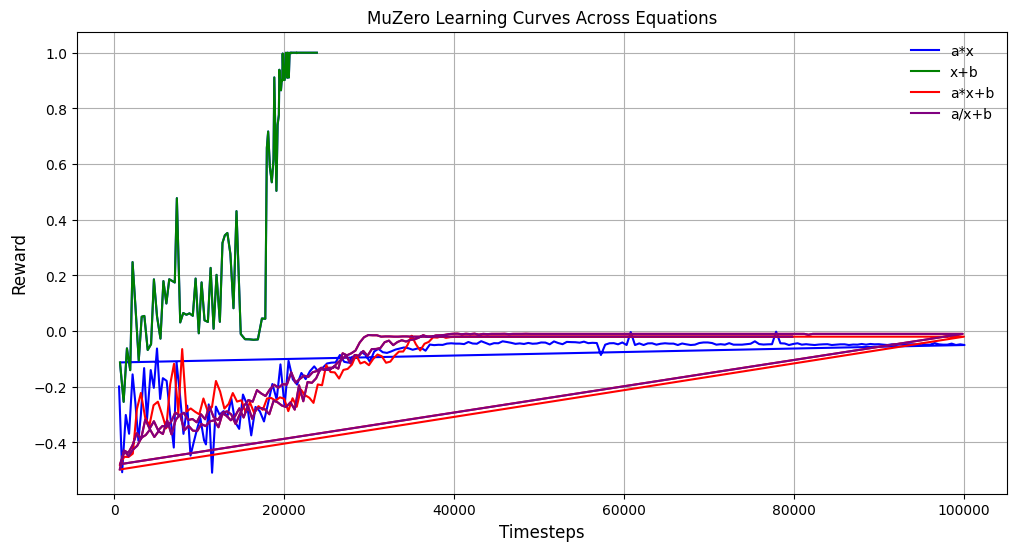

In [83]:
import os
import matplotlib.pyplot as plt

# Path to the base experiment logs directory
base_data_dir = "/Users/Kev/Documents/research/LightZero/data_muzero/main_env"

# List of equations to process
eqn_list = ["a*x", "x+b", "a*x+b", "a/x+b"]  # Modify as needed

# Colors for different equations
colors = ["blue", "green", "red", "purple", "orange"]

# Initialize the figure
plt.figure(figsize=(12, 6))

# Iterate over each equation and extract learning curve data
for idx, eqn in enumerate(eqn_list):
    if eqn == 'a/x+b':
        data_dir = os.path.join(base_data_dir, eqn+'/_250320_140535')
    else:
        data_dir = os.path.join(base_data_dir, eqn)
    collector_log_dir = os.path.join(data_dir, "log", "collector")
    collector_log_file = os.path.join(collector_log_dir, "collector_logger.txt")

    # Initialize storage for reward statistics and episode counts
    mean_rewards, min_rewards, max_rewards, timesteps = [], [], [], []

    # Read the log file if it exists
    if os.path.isfile(collector_log_file):
        with open(collector_log_file, "r") as f:
            for line in f:
                if "reward_mean" in line:
                    mean_rewards.append(float(line.split(":")[-1].strip()))
                elif "reward_min" in line:
                    min_rewards.append(float(line.split(":")[-1].strip()))
                elif "reward_max" in line:
                    max_rewards.append(float(line.split(":")[-1].strip()))
                elif "total_envstep_count" in line:
                    timesteps.append(int(line.split(":")[-1].strip()))

        # Ensure lists are not empty before plotting
        if mean_rewards and timesteps:
            # Plot the learning curve with error bars
            plt.errorbar(
                timesteps, mean_rewards, fmt="-", capsize=5, 
                label=f"{eqn}", color=colors[idx % len(colors)]
            )
            # plt.errorbar(
            #     timesteps, max_rewards, fmt="--", capsize=5, 
            #     label=f"{eqn}", color=colors[idx % len(colors)]
            # )
            # plt.fill_between(
            #     timesteps, min_rewards, max_rewards, 
            #     color=colors[idx % len(colors)], alpha=0.2
            # )

            # Find first occurrence where max reward reaches >= 1
            for i, reward in enumerate(max_rewards):
                if reward >= 1:
                    print(f"{eqn}: First max reward ≥ 1 at timestep {timesteps[i]}")
                    break

    else:
        print(f"Skipping {eqn}: No log file found at {collector_log_file}")

# Plot settings
plt.xlabel("Timesteps")
plt.ylabel("Reward")
plt.title("MuZero Learning Curves Across Equations")
plt.legend()
plt.grid(True)
plt.show()

Skipping a*x: No log file found at /Users/Kev/Documents/research/LightZero/data_muzero/main_env/a*x/log/collector/collector_logger.txt
Skipping x+b: No log file found at /Users/Kev/Documents/research/LightZero/data_muzero/main_env/x+b/log/collector/collector_logger.txt
a*x+b: First max reward ≥ 1 at timestep 5115


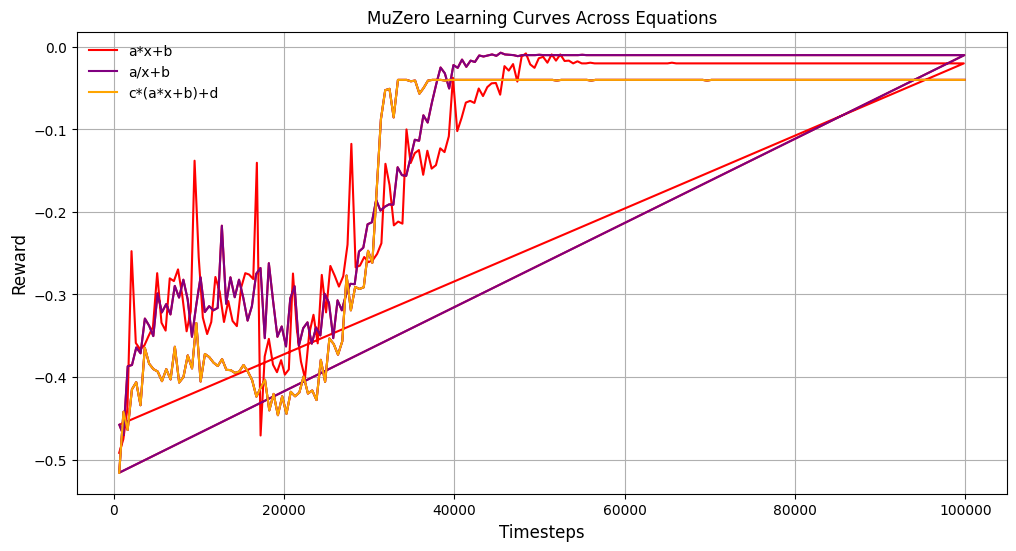

In [85]:
import os
import matplotlib.pyplot as plt

# Path to the base experiment logs directory
base_data_dir = "/Users/Kev/Documents/research/LightZero/data_muzero/main_env"

# List of equations to process
eqn_list = ["a*x", "x+b", "a*x+b", "a/x+b", 'c*(a*x+b)+d']  # Modify as needed

# Colors for different equations
colors = ["blue", "green", "red", "purple", "orange"]

# Initialize the figure
plt.figure(figsize=(12, 6))

# Iterate over each equation and extract learning curve data
for idx, eqn in enumerate(eqn_list):
    data_dir = os.path.join(base_data_dir, eqn)
    collector_log_dir = os.path.join(data_dir, "log", "collector")
    collector_log_file = os.path.join(collector_log_dir, "collector_logger.txt")

    # Initialize storage for reward statistics and episode counts
    mean_rewards, min_rewards, max_rewards, timesteps = [], [], [], []

    # Read the log file if it exists
    if os.path.isfile(collector_log_file):
        with open(collector_log_file, "r") as f:
            for line in f:
                if "reward_mean" in line:
                    mean_rewards.append(float(line.split(":")[-1].strip()))
                elif "reward_min" in line:
                    min_rewards.append(float(line.split(":")[-1].strip()))
                elif "reward_max" in line:
                    max_rewards.append(float(line.split(":")[-1].strip()))
                elif "total_envstep_count" in line:
                    timesteps.append(int(line.split(":")[-1].strip()))

        # Ensure lists are not empty before plotting
        if mean_rewards and timesteps:
            # Plot the learning curve with error bars
            plt.errorbar(
                timesteps, mean_rewards, fmt="-", capsize=5, 
                label=f"{eqn}", color=colors[idx % len(colors)]
            )
            # plt.errorbar(
            #     timesteps, max_rewards, fmt="--", capsize=5, 
            #     label=f"{eqn}", color=colors[idx % len(colors)]
            # )
            # plt.fill_between(
            #     timesteps, min_rewards, max_rewards, 
            #     color=colors[idx % len(colors)], alpha=0.2
            # )

            # Find first occurrence where max reward reaches >= 1
            for i, reward in enumerate(max_rewards):
                if reward >= 1:
                    print(f"{eqn}: First max reward ≥ 1 at timestep {timesteps[i]}")
                    break

    else:
        print(f"Skipping {eqn}: No log file found at {collector_log_file}")

# Plot settings
plt.xlabel("Timesteps")
plt.ylabel("Reward")
plt.title("MuZero Learning Curves Across Equations")
plt.legend()
plt.grid(True)
plt.show()

a*x: First max reward ≥ 1 at timestep 488
Skipping x+b: No log file found at /Users/Kev/Documents/research/LightZero/data_muzero/main_env/x+b/log/collector/collector_logger.txt
Skipping a*x+b: No log file found at /Users/Kev/Documents/research/LightZero/data_muzero/main_env/a*x+b/log/collector/collector_logger.txt
Skipping a/x+b: No log file found at /Users/Kev/Documents/research/LightZero/data_muzero/main_env/a/x+b/log/collector/collector_logger.txt
Skipping c*(a*x+b)+d: No log file found at /Users/Kev/Documents/research/LightZero/data_muzero/main_env/c*(a*x+b)+d/log/collector/collector_logger.txt


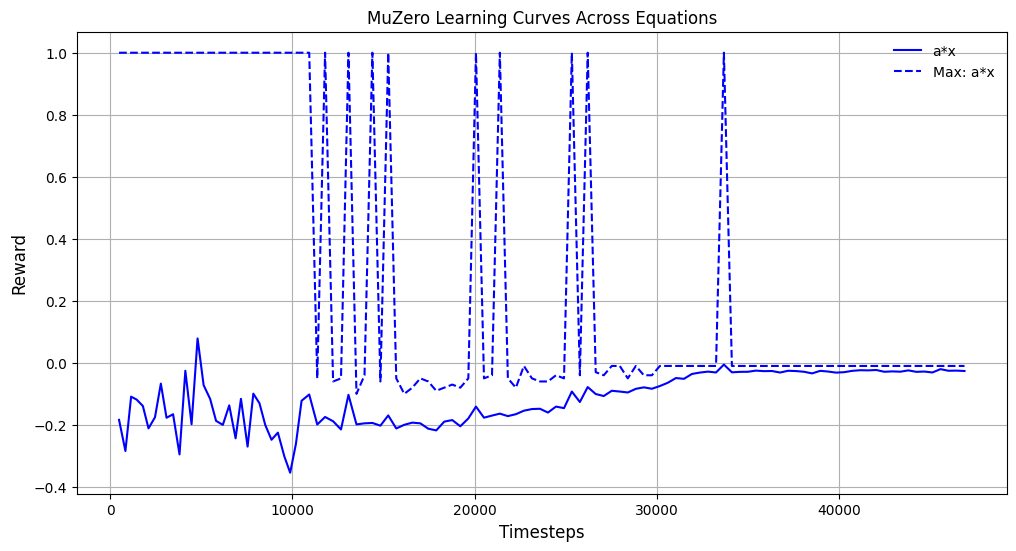

In [113]:
import os
import matplotlib.pyplot as plt

# Path to the base experiment logs directory
base_data_dir = "/Users/Kev/Documents/research/LightZero/data_muzero/main_env"

# List of equations to process
eqn_list = ["a*x", "x+b", "a*x+b", "a/x+b", 'c*(a*x+b)+d']  # Modify as needed

# Colors for different equations
colors = ["blue", "green", "red", "purple", "orange"]

# Initialize the figure
plt.figure(figsize=(12, 6))

# Iterate over each equation and extract learning curve data
for idx, eqn in enumerate(eqn_list):
    data_dir = os.path.join(base_data_dir, eqn)
    collector_log_dir = os.path.join(data_dir, "log", "collector")
    collector_log_file = os.path.join(collector_log_dir, "collector_logger.txt")

    # Initialize storage for reward statistics and episode counts
    mean_rewards, min_rewards, max_rewards, timesteps = [], [], [], []

    # Read the log file if it exists
    if os.path.isfile(collector_log_file):
        with open(collector_log_file, "r") as f:
            for line in f:
                if "reward_mean" in line:
                    mean_rewards.append(float(line.split(":")[-1].strip()))
                elif "reward_min" in line:
                    min_rewards.append(float(line.split(":")[-1].strip()))
                elif "reward_max" in line:
                    max_rewards.append(float(line.split(":")[-1].strip()))
                elif "total_envstep_count" in line:
                    timesteps.append(int(line.split(":")[-1].strip()))

        # Ensure lists are not empty before plotting
        if mean_rewards and timesteps:
            # Plot the learning curve with error bars
            plt.errorbar(
                timesteps, mean_rewards, fmt="-", capsize=5, 
                label=f"{eqn}", color=colors[idx % len(colors)]
            )
            plt.errorbar(
                timesteps, max_rewards, fmt="--", capsize=5, 
                label=f"Max: {eqn}", color=colors[idx % len(colors)]
            )
            # plt.fill_between(
            #     timesteps, min_rewards, max_rewards, 
            #     color=colors[idx % len(colors)], alpha=0.2
            # )

            # Find first occurrence where max reward reaches >= 1
            for i, reward in enumerate(max_rewards):
                if reward >= 1:
                    print(f"{eqn}: First max reward ≥ 1 at timestep {timesteps[i]}")
                    break

    else:
        print(f"Skipping {eqn}: No log file found at {collector_log_file}")

# Plot settings
plt.xlabel("Timesteps")
plt.ylabel("Reward")
plt.title("MuZero Learning Curves Across Equations")
plt.legend()
plt.grid(True)
plt.show()

a*x: First max reward ≥ 1 at timestep 260
x+b: First max reward ≥ 1 at timestep 247
a*x+b: First max reward ≥ 1 at timestep 2186
Skipping c*(a*x+b)+d: No log file found at /Users/Kev/Documents/research/LightZero/data_muzero/main_env/c*(a*x+b)+d/log/collector/collector_logger.txt


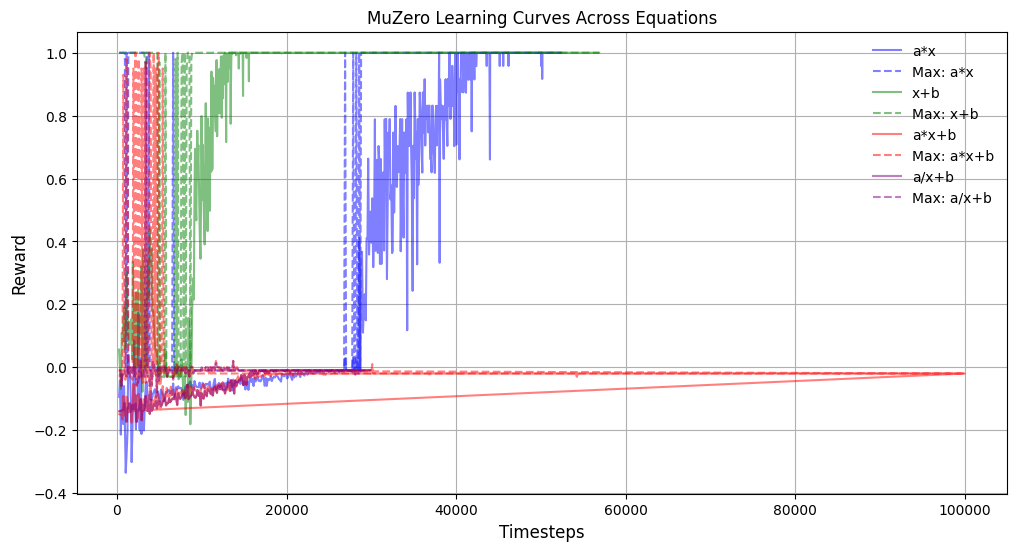

In [195]:
import os
import matplotlib.pyplot as plt

# Path to the base experiment logs directory
base_data_dir = "/Users/Kev/Documents/research/LightZero/data_muzero/main_env"

# List of equations to process
eqn_list = ["a*x", "x+b", "a*x+b", "a/x+b", 'c*(a*x+b)+d']  # Modify as needed

# Colors for different equations
colors = ["blue", "green", "red", "purple", "orange"]

# Initialize the figure
plt.figure(figsize=(12, 6))

# Iterate over each equation and extract learning curve data
for idx, eqn in enumerate(eqn_list):
    data_dir = os.path.join(base_data_dir, eqn)
    collector_log_dir = os.path.join(data_dir, "log", "collector")
    collector_log_file = os.path.join(collector_log_dir, "collector_logger.txt")

    # Initialize storage for reward statistics and episode counts
    mean_rewards, min_rewards, max_rewards, timesteps = [], [], [], []

    # Read the log file if it exists
    if os.path.isfile(collector_log_file):
        with open(collector_log_file, "r") as f:
            for line in f:
                if "reward_mean" in line:
                    mean_rewards.append(float(line.split(":")[-1].strip()))
                elif "reward_min" in line:
                    min_rewards.append(float(line.split(":")[-1].strip()))
                elif "reward_max" in line:
                    max_rewards.append(float(line.split(":")[-1].strip()))
                elif "total_envstep_count" in line:
                    timesteps.append(int(line.split(":")[-1].strip()))

        # Ensure lists are not empty before plotting
        if mean_rewards and timesteps:
            # Plot the learning curve with error bars
            plt.errorbar(
                timesteps, mean_rewards, fmt="-", capsize=5, alpha=0.5,
                label=f"{eqn}", color=colors[idx % len(colors)]
            )
            plt.errorbar(
                timesteps, max_rewards, fmt="--", capsize=5, alpha=0.5,
                label=f"Max: {eqn}", color=colors[idx % len(colors)]
            )
            # plt.fill_between(
            #     timesteps, min_rewards, max_rewards, 
            #     color=colors[idx % len(colors)], alpha=0.2
            # )

            # Find first occurrence where max reward reaches >= 1
            for i, reward in enumerate(max_rewards):
                if reward >= 1:
                    print(f"{eqn}: First max reward ≥ 1 at timestep {timesteps[i]}")
                    break

    else:
        print(f"Skipping {eqn}: No log file found at {collector_log_file}")

# Plot settings
plt.xlabel("Timesteps")
plt.ylabel("Reward")
plt.title("MuZero Learning Curves Across Equations")
plt.legend()
plt.grid(True)
plt.show()

a*x: First max reward ≥ 1 at timestep 234
x+b: First max reward ≥ 1 at timestep 255
Skipping a/x+b: No log file found at /Users/Kev/Documents/research/LightZero/data_muzero/main_env/a/x+b/log/collector/collector_logger.txt
Skipping c*(a*x+b)+d: No log file found at /Users/Kev/Documents/research/LightZero/data_muzero/main_env/c*(a*x+b)+d/log/collector/collector_logger.txt


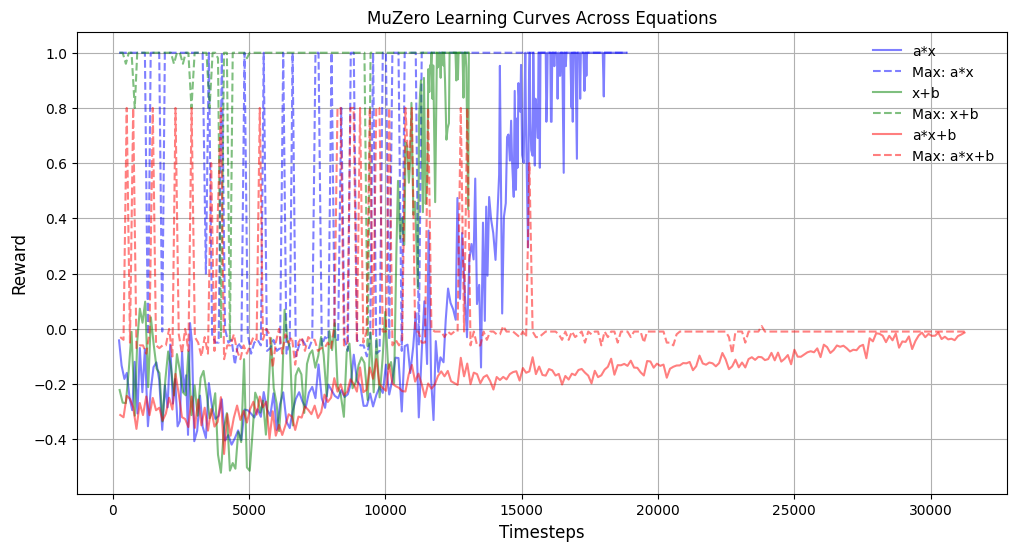

In [230]:
import os
import matplotlib.pyplot as plt

# Path to the base experiment logs directory
base_data_dir = "/Users/Kev/Documents/research/LightZero/data_muzero/main_env"

# List of equations to process
eqn_list = ["a*x", "x+b", "a*x+b", "a/x+b", 'c*(a*x+b)+d']  # Modify as needed

# Colors for different equations
colors = ["blue", "green", "red", "purple", "orange"]

# Initialize the figure
plt.figure(figsize=(12, 6))

# Iterate over each equation and extract learning curve data
for idx, eqn in enumerate(eqn_list):
    data_dir = os.path.join(base_data_dir, eqn)
    collector_log_dir = os.path.join(data_dir, "log", "collector")
    collector_log_file = os.path.join(collector_log_dir, "collector_logger.txt")

    # Initialize storage for reward statistics and episode counts
    mean_rewards, min_rewards, max_rewards, timesteps = [], [], [], []

    # Read the log file if it exists
    if os.path.isfile(collector_log_file):
        with open(collector_log_file, "r") as f:
            for line in f:
                if "reward_mean" in line:
                    mean_rewards.append(float(line.split(":")[-1].strip()))
                elif "reward_min" in line:
                    min_rewards.append(float(line.split(":")[-1].strip()))
                elif "reward_max" in line:
                    max_rewards.append(float(line.split(":")[-1].strip()))
                elif "total_envstep_count" in line:
                    timesteps.append(int(line.split(":")[-1].strip()))

        # Ensure lists are not empty before plotting
        if mean_rewards and timesteps:
            # Plot the learning curve with error bars
            plt.errorbar(
                timesteps, mean_rewards, fmt="-", capsize=5, alpha=0.5,
                label=f"{eqn}", color=colors[idx % len(colors)]
            )
            plt.errorbar(
                timesteps, max_rewards, fmt="--", capsize=5, alpha=0.5,
                label=f"Max: {eqn}", color=colors[idx % len(colors)]
            )
            # plt.fill_between(
            #     timesteps, min_rewards, max_rewards, 
            #     color=colors[idx % len(colors)], alpha=0.2
            # )

            # Find first occurrence where max reward reaches >= 1
            for i, reward in enumerate(max_rewards):
                if reward >= 1:
                    print(f"{eqn}: First max reward ≥ 1 at timestep {timesteps[i]}")
                    break

    else:
        print(f"Skipping {eqn}: No log file found at {collector_log_file}")

# Plot settings
plt.xlabel("Timesteps")
plt.ylabel("Reward")
plt.title("MuZero Learning Curves Across Equations")
plt.legend()
plt.grid(True)
plt.show()